# COVID-19 Pandemic Data Analysis
### Predictions, Anomaly Detection & Outlier Identification

In [1]:
!pip install statsmodels -q

In [8]:
import os
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats


In [9]:
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.ar_model import AutoReg
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import IsolationForest, RandomForestRegressor


## 1. Load Datasets

In [10]:
# Load all three datasets
covid_data        = pd.read_csv('/content/covid_19_india.csv')
vaccine_state_data = pd.read_csv('/content/covid_vaccine_statewise.csv')
state_test_data   = pd.read_csv('/content/StatewiseTestingDetails.csv')


## 2. Data Preprocessing

In [11]:
# Parse dates
covid_data['Date'] = pd.to_datetime(covid_data['Date'], errors='coerce', dayfirst=True)
vaccine_state_data['Updated On'] = pd.to_datetime(vaccine_state_data['Updated On'], errors='coerce', dayfirst=True)
state_test_data['Date'] = pd.to_datetime(state_test_data['Date'], errors='coerce', dayfirst=True)

# Numeric conversions for covid data
for col in ['Cured', 'Deaths', 'Confirmed']:
    covid_data[col] = pd.to_numeric(covid_data[col], errors='coerce')

# Numeric conversions for testing data
for col in ['TotalSamples', 'Negative', 'Positive']:
    state_test_data[col] = pd.to_numeric(state_test_data[col], errors='coerce')

# Clean vaccine column names and convert to numeric
vaccine_state_data.columns = vaccine_state_data.columns.str.strip()
vaccine_state_data.columns = vaccine_state_data.columns.str.replace(r"\s+", " ", regex=True)

vaccine_state_data.rename(columns={
    'Sites': 'Sites',
    'Covaxin (Doses Administered)': 'Covaxin (Doses Administered)'
}, inplace=True)

vax_numeric = [
    'Total Doses Administered', 'Sessions', 'Sites', 'First Dose Administered',
    'Second Dose Administered', 'Male (Doses Administered)', 'Female (Doses Administered)',
    'Transgender (Doses Administered)', 'Covaxin (Doses Administered)',
    'CoviShield (Doses Administered)', 'Sputnik V (Doses Administered)', 'AEFI',
    '18-44 Years (Doses Administered)', '45-60 Years (Doses Administered)',
    '60+ Years (Doses Administered)', 'Total Individuals Vaccinated'
]

for col in vax_numeric:
    if col in vaccine_state_data.columns:
        vaccine_state_data[col] = pd.to_numeric(vaccine_state_data[col], errors='coerce')

In [12]:
# Quick look at the datasets
for name, df in [("COVID-19 India", covid_data),
                 ("Vaccine Statewise", vaccine_state_data),
                 ("Statewise Testing", state_test_data)]:
    print(f"\n{'='*40}")
    print(f"  {name}  |  Shape: {df.shape}")
    print('='*40)
    print(df.head(3).to_string())



  COVID-19 India  |  Shape: (18110, 9)
   Sno       Date     Time State/UnionTerritory ConfirmedIndianNational ConfirmedForeignNational  Cured  Deaths  Confirmed
0    1 2020-01-30  6:00 PM               Kerala                       1                        0      0       0          1
1    2 2020-01-31  6:00 PM               Kerala                       1                        0      0       0          1
2    3 2020-02-01  6:00 PM               Kerala                       2                        0      0       0          2

  Vaccine Statewise  |  Shape: (7845, 24)
  Updated On  State  Total Doses Administered  Sessions   Sites  First Dose Administered  Second Dose Administered  Male (Doses Administered)  Female (Doses Administered)  Transgender (Doses Administered)  Covaxin (Doses Administered)  CoviShield (Doses Administered)  Sputnik V (Doses Administered)  AEFI  18-44 Years (Doses Administered)  45-60 Years (Doses Administered)  60+ Years (Doses Administered)  18-44 Years(Indivi

In [13]:
# State counts across datasets
print("States in covid_data:        ", covid_data['State/UnionTerritory'].nunique())
print("States in vaccine_state_data:", vaccine_state_data['State'].nunique())
print("States in state_test_data:   ", state_test_data['State'].nunique())


States in covid_data:         46
States in vaccine_state_data: 37
States in state_test_data:    36


In [14]:
print(covid_data['State/UnionTerritory'].unique())
print(vaccine_state_data['State'].unique())
print(state_test_data['State'].unique())
print((covid_data['State/UnionTerritory'].unique().shape))
print((vaccine_state_data['State'].unique().shape))
print((state_test_data['State'].unique().shape))

['Kerala' 'Telengana' 'Delhi' 'Rajasthan' 'Uttar Pradesh' 'Haryana'
 'Ladakh' 'Tamil Nadu' 'Karnataka' 'Maharashtra' 'Punjab'
 'Jammu and Kashmir' 'Andhra Pradesh' 'Uttarakhand' 'Odisha' 'Puducherry'
 'West Bengal' 'Chhattisgarh' 'Chandigarh' 'Gujarat' 'Himachal Pradesh'
 'Madhya Pradesh' 'Bihar' 'Manipur' 'Mizoram'
 'Andaman and Nicobar Islands' 'Goa' 'Unassigned' 'Assam' 'Jharkhand'
 'Arunachal Pradesh' 'Tripura' 'Nagaland' 'Meghalaya'
 'Dadra and Nagar Haveli and Daman and Diu'
 'Cases being reassigned to states' 'Sikkim' 'Daman & Diu' 'Lakshadweep'
 'Telangana' 'Dadra and Nagar Haveli' 'Bihar****' 'Madhya Pradesh***'
 'Himanchal Pradesh' 'Karanataka' 'Maharashtra***']
['India' 'Andaman and Nicobar Islands' 'Andhra Pradesh'
 'Arunachal Pradesh' 'Assam' 'Bihar' 'Chandigarh' 'Chhattisgarh'
 'Dadra and Nagar Haveli and Daman and Diu' 'Delhi' 'Goa' 'Gujarat'
 'Haryana' 'Himachal Pradesh' 'Jammu and Kashmir' 'Jharkhand' 'Karnataka'
 'Kerala' 'Ladakh' 'Lakshadweep' 'Madhya Pradesh' 'Mahar

## 3. Exploratory Visualization

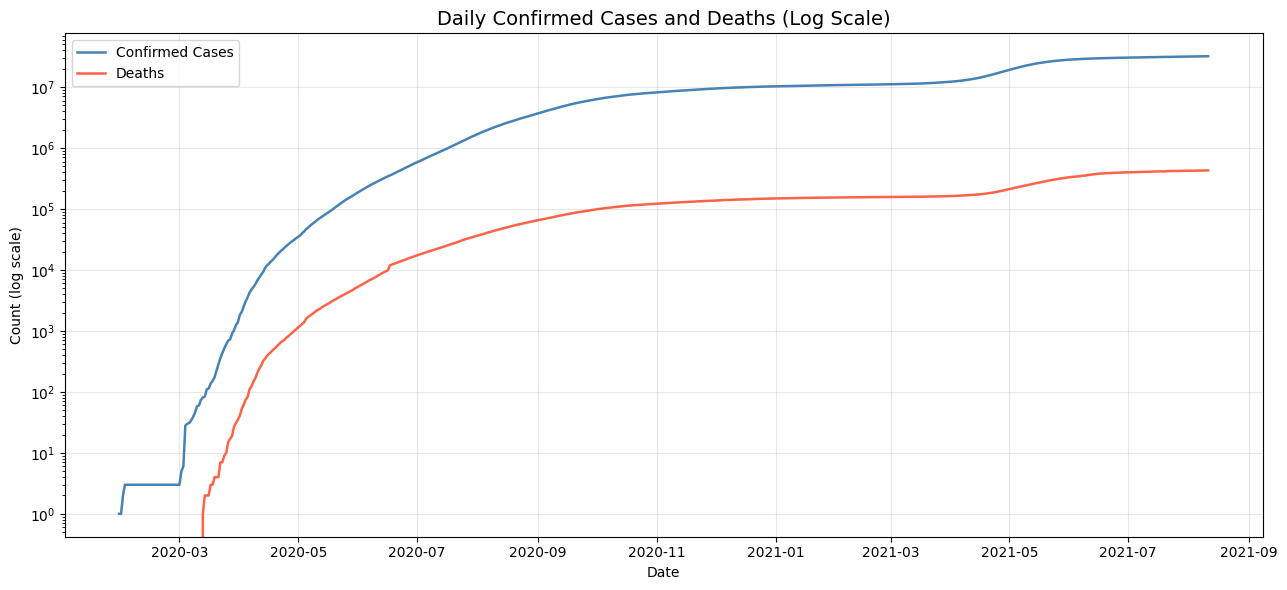

In [15]:
# Aggregate daily totals across all states
daily_totals = covid_data.groupby('Date')[['Confirmed', 'Deaths']].sum().sort_index()

fig, ax = plt.subplots(figsize=(13, 6))
ax.plot(daily_totals.index, daily_totals['Confirmed'], linewidth=1.8, label='Confirmed Cases', color='steelblue')
ax.plot(daily_totals.index, daily_totals['Deaths'],    linewidth=1.8, label='Deaths',          color='tomato')
ax.set_yscale('log')
ax.set_title('Daily Confirmed Cases and Deaths (Log Scale)', fontsize=14)
ax.set_xlabel('Date')
ax.set_ylabel('Count (log scale)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


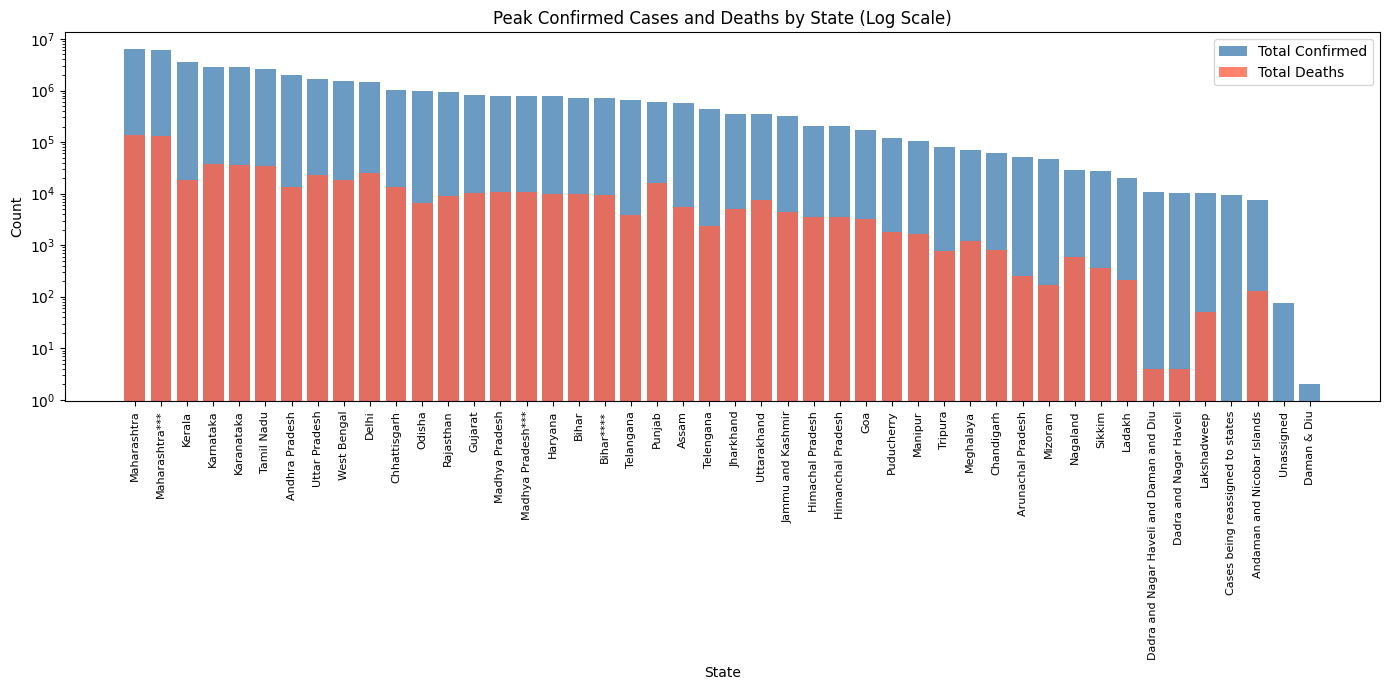

In [16]:
# State-wise peak confirmed cases and deaths
state_peaks = covid_data.groupby('State/UnionTerritory')[['Confirmed', 'Deaths']].max()
state_peaks = state_peaks.sort_values('Confirmed', ascending=False)

fig, ax = plt.subplots(figsize=(14, 7))
x_pos = range(len(state_peaks))
ax.bar(x_pos, state_peaks['Confirmed'], label='Total Confirmed', color='steelblue', alpha=0.8)
ax.bar(x_pos, state_peaks['Deaths'],    label='Total Deaths',    color='tomato',    alpha=0.8)
ax.set_xticks(list(x_pos))
ax.set_xticklabels(state_peaks.index, rotation=90, fontsize=8)
ax.set_yscale('log')
ax.set_title('Peak Confirmed Cases and Deaths by State (Log Scale)')
ax.set_xlabel('State')
ax.set_ylabel('Count')
ax.legend()
plt.tight_layout()
plt.show()


## 4. Time-Series Forecasting
### 4a. ARIMA Model

ARIMA  =>  RMSE: 30,311   MAE: 23,068


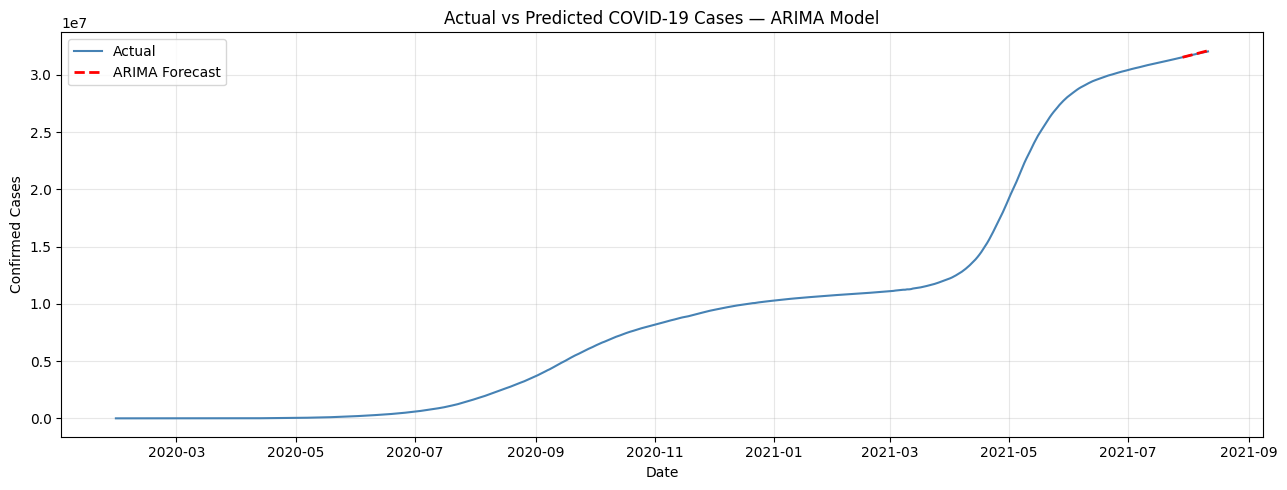

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error, mean_absolute_error

# Config
HORIZON  = 14   # test window (days)
AR_ORDER = 7    # AR lags

# Prepare
ts = covid_data.copy().set_index('Date').resample('D').sum()
train_ts = ts.iloc[:-HORIZON]
test_ts  = ts.iloc[-HORIZON:]

# Fit ARIMA
arima_model = ARIMA(
    endog=train_ts['Confirmed'],
    exog=train_ts[['Deaths', 'Cured']],
    order=(AR_ORDER, 1, 1)
)
arima_fit = arima_model.fit()

# Forecast
arima_preds = arima_fit.forecast(steps=HORIZON, exog=test_ts[['Deaths', 'Cured']])

# Metrics
rmse_arima = np.sqrt(mean_squared_error(test_ts['Confirmed'], arima_preds))
mae_arima  = mean_absolute_error(test_ts['Confirmed'], arima_preds)
print(f"ARIMA  =>  RMSE: {rmse_arima:,.0f}   MAE: {mae_arima:,.0f}")

# Plot
plt.figure(figsize=(13, 5))
plt.plot(ts.index,        ts['Confirmed'],  label='Actual',          color='steelblue')
plt.plot(test_ts.index,   arima_preds,       label='ARIMA Forecast',  color='red', linestyle='--', linewidth=2)
plt.title('Actual vs Predicted COVID-19 Cases — ARIMA Model')
plt.xlabel('Date'); plt.ylabel('Confirmed Cases')
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()


### 4b. SARIMAX Model

SARIMAX  =>  RMSE: 47,965   MAE: 36,855


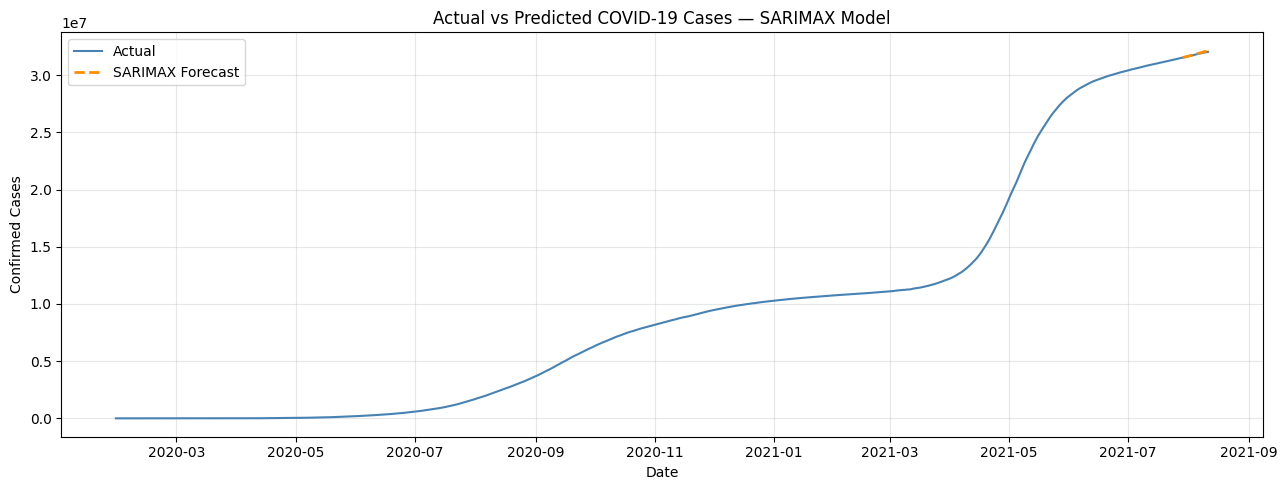

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_squared_error, mean_absolute_error

#  Config
HORIZON        = 14
AR_LAGS        = 5
SEAS_ORDER     = (5, 1, 1, 7)   # weekly seasonality

#  Prepare
ts2 = covid_data.copy().set_index('Date')
if 'Sno' in ts2.columns:
    ts2 = ts2.drop('Sno', axis=1)
ts2 = ts2.resample('D').sum()

train_ts2 = ts2.iloc[:-HORIZON]
test_ts2  = ts2.iloc[-HORIZON:]

#  Fit SARIMAX
sarimax_model = SARIMAX(
    endog=train_ts2['Confirmed'],
    exog=train_ts2[['Deaths', 'Cured']],
    order=(AR_LAGS, 1, 1),
    seasonal_order=SEAS_ORDER
)
sarimax_fit = sarimax_model.fit(disp=False)

#  Forecast
sarimax_preds = sarimax_fit.forecast(steps=HORIZON, exog=test_ts2[['Deaths', 'Cured']])

#  Metrics
rmse_sarimax = np.sqrt(mean_squared_error(test_ts2['Confirmed'], sarimax_preds))
mae_sarimax  = mean_absolute_error(test_ts2['Confirmed'], sarimax_preds)
print(f"SARIMAX  =>  RMSE: {rmse_sarimax:,.0f}   MAE: {mae_sarimax:,.0f}")

#  Plot
plt.figure(figsize=(13, 5))
plt.plot(ts2.index,       ts2['Confirmed'],   label='Actual',           color='steelblue')
plt.plot(test_ts2.index,  sarimax_preds,       label='SARIMAX Forecast', color='darkorange', linestyle='--', linewidth=2)
plt.title('Actual vs Predicted COVID-19 Cases — SARIMAX Model')
plt.xlabel('Date'); plt.ylabel('Confirmed Cases')
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()


### 4c. AutoReg Model

AutoReg  =>  RMSE: 38,243   MAE: 28,300


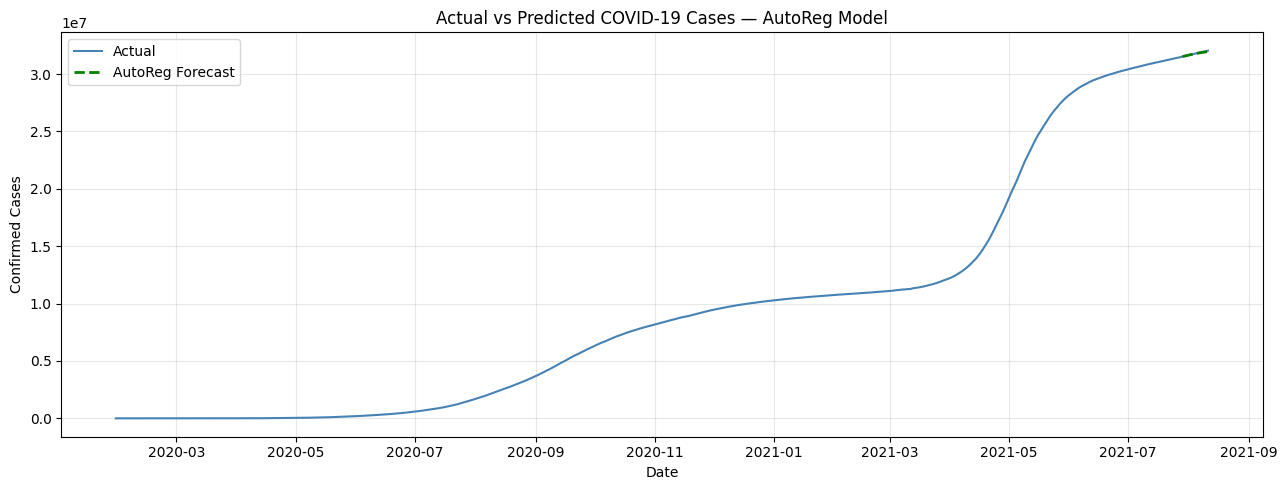

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.ar_model import AutoReg
from sklearn.metrics import mean_squared_error, mean_absolute_error

# Config
HORIZON     = 14
AR_LAGS     = 7
TARGET_COL  = 'Confirmed'

# Prepare
ts3 = covid_data.copy().set_index('Date')
if 'Sno' in ts3.columns:
    ts3 = ts3.drop('Sno', axis=1)
ts3 = ts3.resample('D').sum()

train_ts3 = ts3.iloc[:-HORIZON]
test_ts3  = ts3.iloc[-HORIZON:]

# Fit AutoReg
ar_model = AutoReg(endog=train_ts3[TARGET_COL], lags=AR_LAGS)
ar_fit   = ar_model.fit()

# Forecast
ar_preds = ar_fit.predict(start=len(train_ts3), end=len(train_ts3) + HORIZON - 1, dynamic=False)

# Metrics
rmse_ar = np.sqrt(mean_squared_error(test_ts3[TARGET_COL], ar_preds))
mae_ar  = mean_absolute_error(test_ts3[TARGET_COL], ar_preds)
print(f"AutoReg  =>  RMSE: {rmse_ar:,.0f}   MAE: {mae_ar:,.0f}")

# Plot
plt.figure(figsize=(13, 5))
plt.plot(ts3.index,      ts3[TARGET_COL], label='Actual',          color='steelblue')
plt.plot(test_ts3.index, ar_preds,         label='AutoReg Forecast', color='green', linestyle='--', linewidth=2)
plt.title('Actual vs Predicted COVID-19 Cases — AutoReg Model')
plt.xlabel('Date'); plt.ylabel('Confirmed Cases')
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()


### 4d. Linear Regression with Lag Features

Linear Regression  =>  RMSE: 6,473   MAE: 5,002


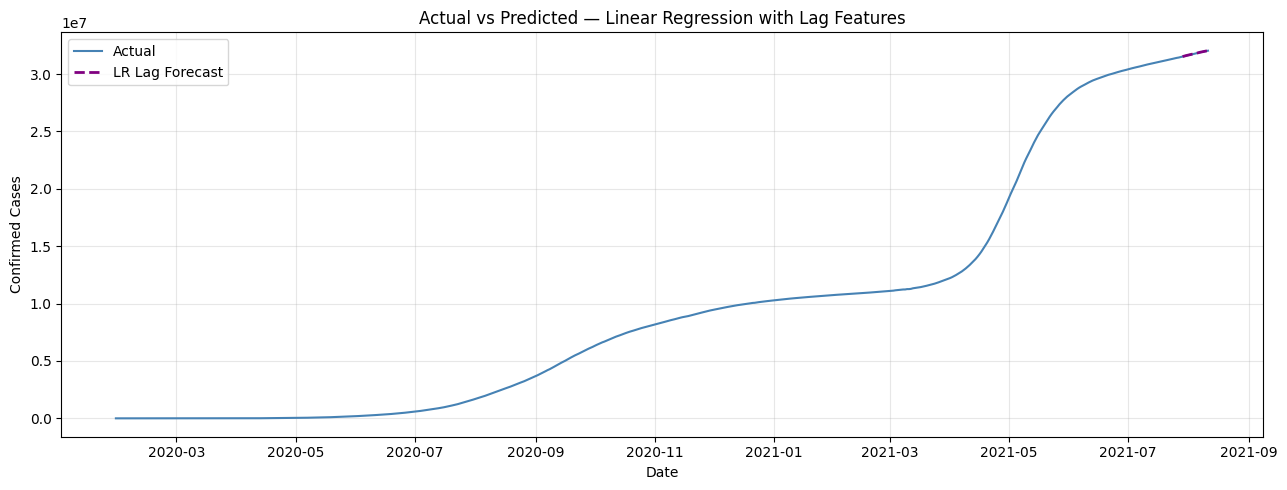

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error

# Config
HORIZON    = 14
N_LAGS     = 7
TARGET_COL = 'Confirmed'

# Prepare with lag features
ts4 = covid_data.copy().set_index('Date').resample('D').sum()
if 'Sno' in ts4.columns:
    ts4 = ts4.drop('Sno', axis=1)

for lag_n in range(1, N_LAGS + 1):
    ts4[f'lag_{lag_n}'] = ts4[TARGET_COL].shift(lag_n)

train_ts4 = ts4.iloc[:-HORIZON].dropna()
test_ts4  = ts4.iloc[-HORIZON:].dropna()

lag_cols = [f'lag_{i}' for i in range(1, N_LAGS + 1)]
numeric_extra = [c for c in ts4.columns if c not in [TARGET_COL] + lag_cols and ts4[c].dtype != object]

feature_cols = lag_cols + numeric_extra

X_train4 = train_ts4[feature_cols]
y_train4 = train_ts4[TARGET_COL]
X_test4  = test_ts4[feature_cols]
y_test4  = test_ts4[TARGET_COL]

# Fit
lr_model = LinearRegression()
lr_model.fit(X_train4, y_train4)
lr_preds = pd.Series(lr_model.predict(X_test4), index=y_test4.index)

# Metrics
rmse_lr = np.sqrt(np.mean((lr_preds - y_test4) ** 2))
mae_lr  = mean_absolute_error(y_test4, lr_preds)
print(f"Linear Regression  =>  RMSE: {rmse_lr:,.0f}   MAE: {mae_lr:,.0f}")

# Plot
plt.figure(figsize=(13, 5))
plt.plot(ts4.index,    ts4[TARGET_COL], label='Actual',         color='steelblue')
plt.plot(lr_preds.index, lr_preds,      label='LR Lag Forecast', color='purple', linestyle='--', linewidth=2)
plt.title('Actual vs Predicted — Linear Regression with Lag Features')
plt.xlabel('Date'); plt.ylabel('Confirmed Cases')
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()


## 5. Anomaly Detection — Isolation Forest (Per State)

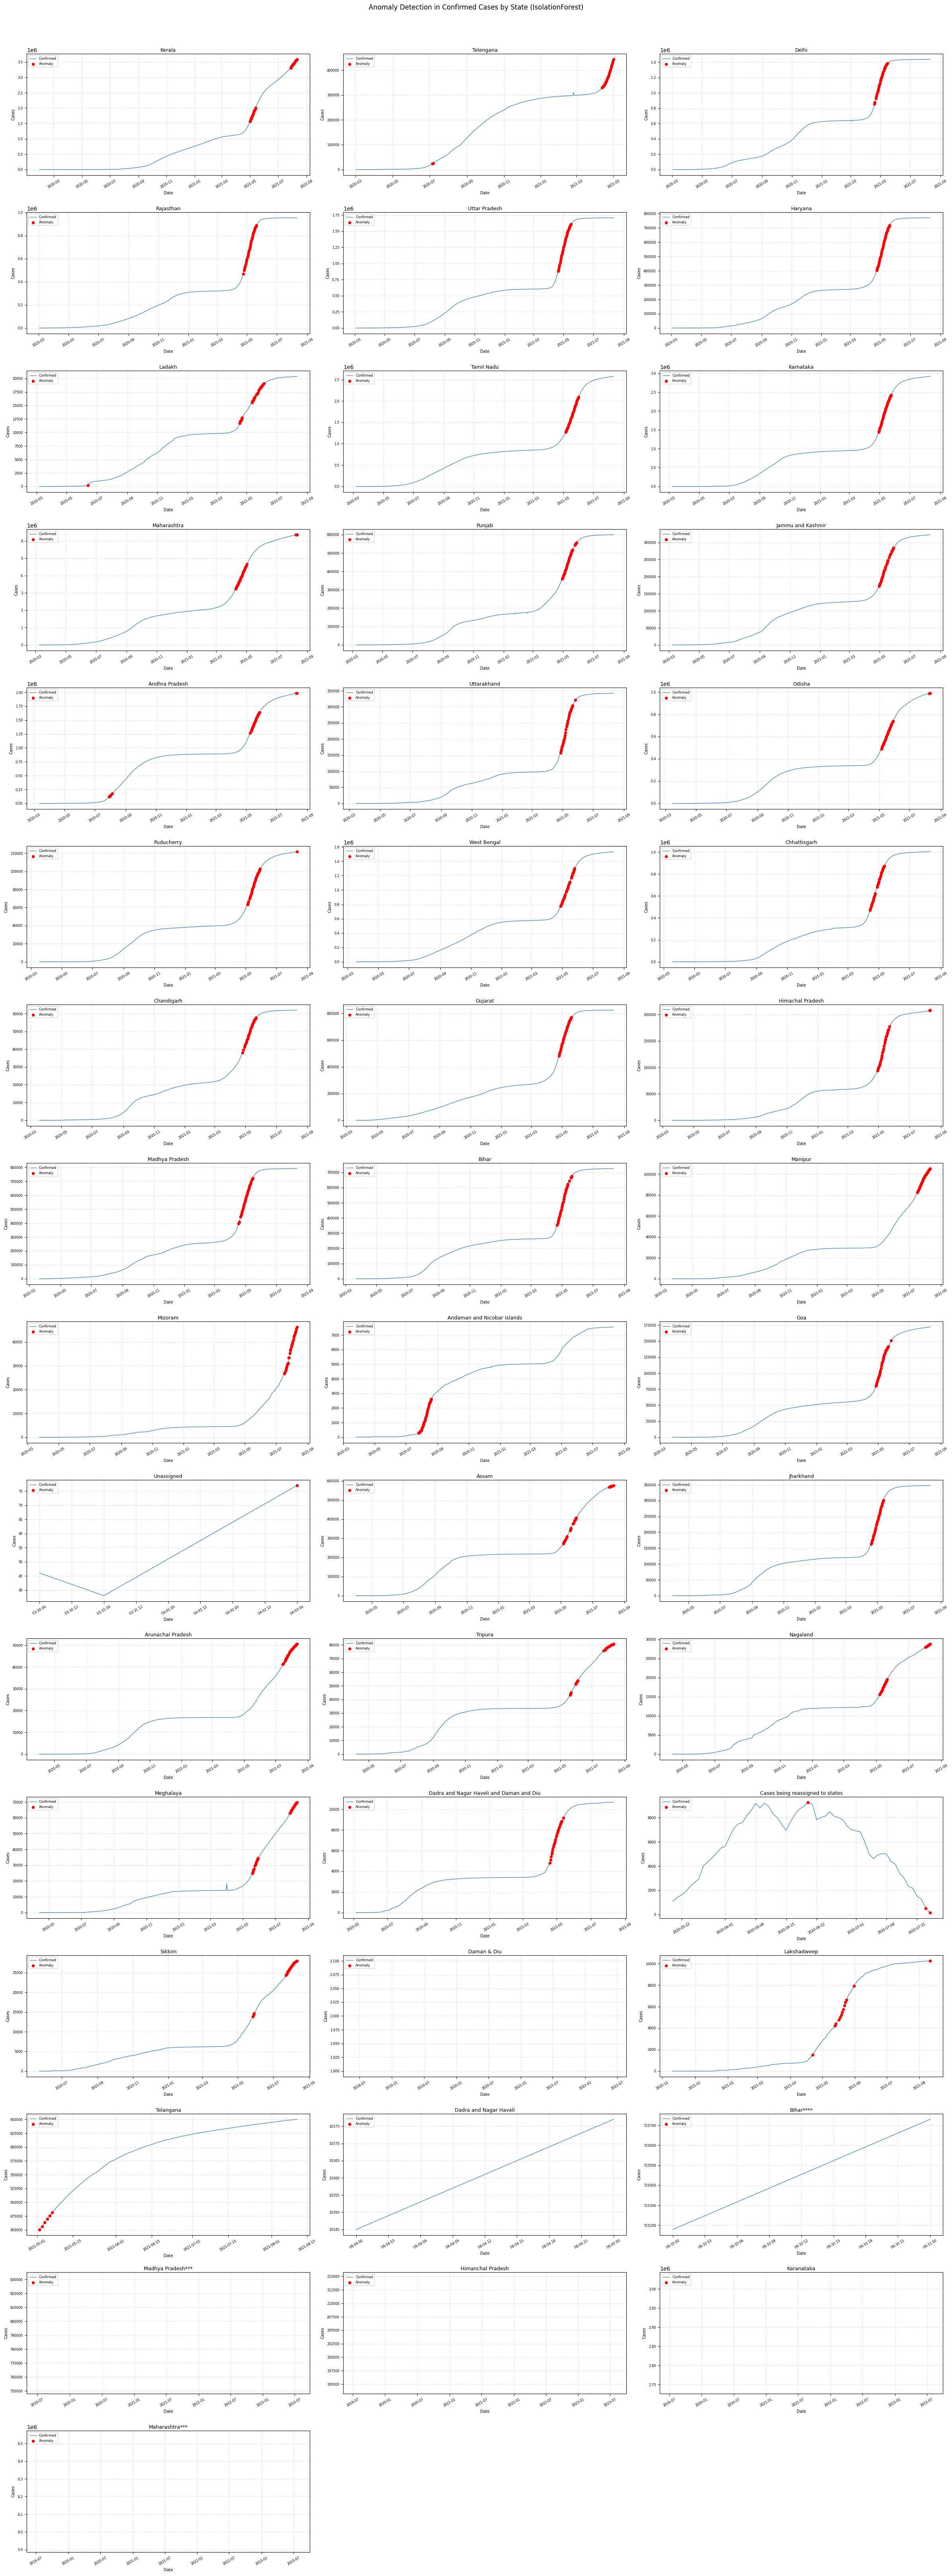

In [21]:
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.ensemble import IsolationForest

df_anom = covid_data.copy()
all_states = df_anom['State/UnionTerritory'].unique()

NCOLS = 3
NROWS = (len(all_states) + NCOLS - 1) // NCOLS

fig, axes = plt.subplots(NROWS, NCOLS, figsize=(24, 4 * NROWS))
axes = axes.flatten()

for idx, state in enumerate(all_states):
    state_df = df_anom.loc[
        df_anom['State/UnionTerritory'] == state, ['Date', 'Confirmed']
    ].dropna(subset=['Confirmed']).copy()

    state_df['Date'] = pd.to_datetime(state_df['Date'], errors='coerce')
    state_df = state_df.set_index('Date').sort_index()

    ax = axes[idx]

    # Fit IsolationForest
    iso = IsolationForest(n_estimators=100, contamination=0.05, random_state=42)
    state_df['is_anomaly'] = iso.fit_predict(state_df[['Confirmed']])

    ax.plot(state_df.index, state_df['Confirmed'],
            label='Confirmed', color='steelblue', linewidth=1)

    anomaly_pts = state_df[state_df['is_anomaly'] == -1]
    ax.scatter(anomaly_pts.index, anomaly_pts['Confirmed'],
               color='red', zorder=5, label='Anomaly', s=20)

    ax.set_title(state, fontsize=9, pad=4)
    ax.set_ylabel('Cases', fontsize=7)
    ax.set_xlabel('Date', fontsize=7)
    ax.tick_params(axis='x', labelsize=6, rotation=30)
    ax.tick_params(axis='y', labelsize=6)
    ax.legend(fontsize=6, loc='upper left')
    ax.grid(True, linestyle='--', alpha=0.4)

# Remove empty axes
for j in range(len(all_states), len(axes)):
    fig.delaxes(axes[j])

plt.suptitle('Anomaly Detection in Confirmed Cases by State (IsolationForest)',
             fontsize=12, y=1.01)
plt.tight_layout(pad=1.0, h_pad=1.5, w_pad=1.0)
plt.show()

## 6. Statistical Outlier Detection — Z-Score Method

Outliers in Confirmed cases: 383
            Confirmed  Confirmed_zscore
Date                                   
2021-03-13    2282191          3.019375
2021-03-14    2297793          3.043153
2021-03-15    2314413          3.068483
2021-03-16    2329464          3.091421
2021-03-17    2347328          3.118647
2021-03-18    2370507          3.153973
2021-03-19    2396340          3.193343
2021-03-20    2422021          3.232482
2021-03-21    2449147          3.273823
2021-03-22    2479682          3.320360

Outliers in Deaths: 316
            Deaths  Deaths_zscore
Date                             
2020-10-02   37056       3.022563
2020-10-03   37480       3.061394
2020-10-04   37758       3.086854
2020-10-05   38084       3.116710
2020-10-06   38347       3.140797
2020-10-07   38717       3.174682
2020-10-08   39072       3.207194
2020-10-09   39430       3.239981
2020-10-10   39732       3.267639
2020-10-11   40040       3.295846


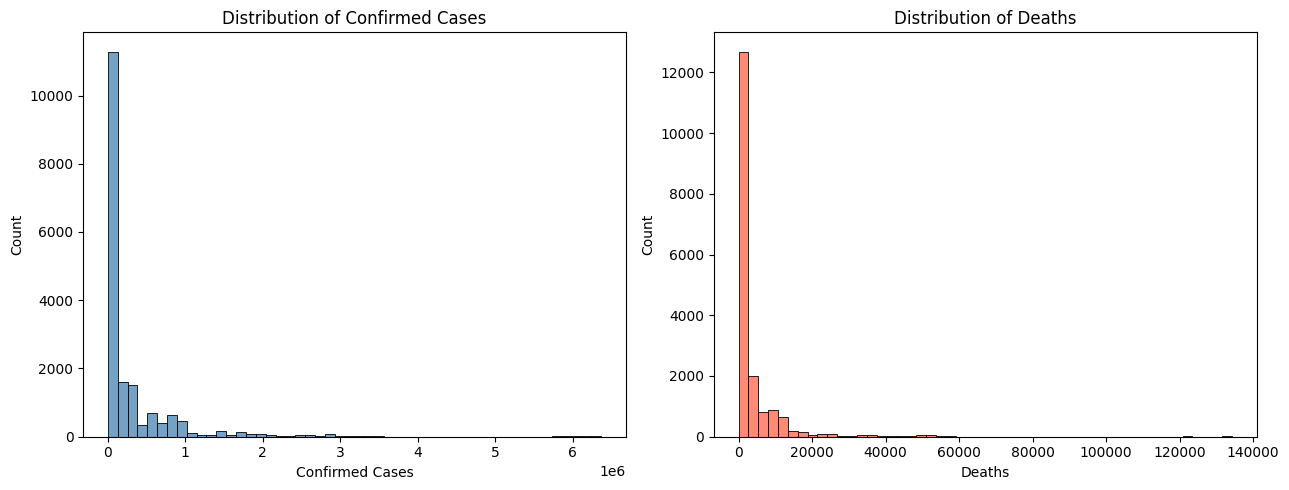

Text(0.5, 1.0, 'Deaths Time Series')

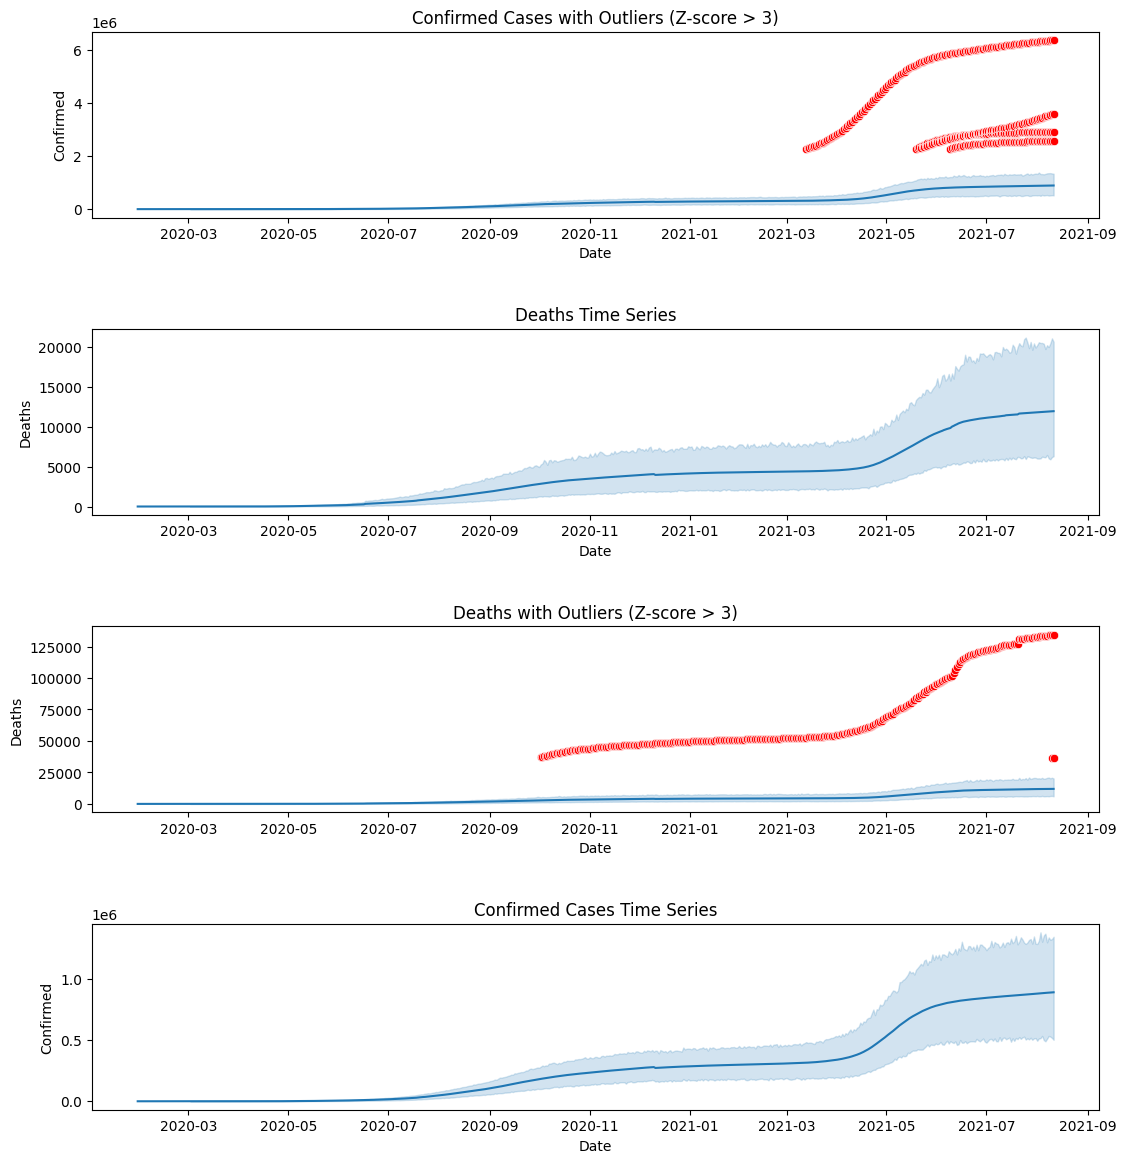

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

df_z = covid_data.copy().set_index('Date')
df_z = df_z.loc['2020-01-30':'2021-08-11']

# Z-score for Confirmed and Deaths
for col in ['Confirmed', 'Deaths']:
    df_z[f'{col}_zscore'] = (df_z[col] - df_z[col].mean()) / df_z[col].std()

THRESHOLD = 3
outliers_confirmed = df_z[df_z['Confirmed_zscore'].abs() > THRESHOLD]
outliers_deaths    = df_z[df_z['Deaths_zscore'].abs()    > THRESHOLD]

print(f"Outliers in Confirmed cases: {len(outliers_confirmed)}")
print(outliers_confirmed[['Confirmed', 'Confirmed_zscore']].head(10))
print(f"\nOutliers in Deaths: {len(outliers_deaths)}")
print(outliers_deaths[['Deaths', 'Deaths_zscore']].head(10))

# Distribution plots
fig, axs = plt.subplots(1, 2, figsize=(13, 5))
sns.histplot(df_z['Confirmed'], bins=50, ax=axs[0], color='steelblue')
axs[0].set_title('Distribution of Confirmed Cases')
axs[0].set_xlabel('Confirmed Cases')

sns.histplot(df_z['Deaths'], bins=50, ax=axs[1], color='tomato')
axs[1].set_title('Distribution of Deaths')
axs[1].set_xlabel('Deaths')
plt.tight_layout(); plt.show()

# Time-series with outliers highlighted
fig, axs = plt.subplots(4, 1, figsize=(13, 14), gridspec_kw={'hspace': 0.6})

sns.lineplot(data=df_z, x=df_z.index, y='Confirmed', ax=axs[0])
sns.scatterplot(data=outliers_confirmed, x=outliers_confirmed.index, y='Confirmed',
                color='red', ax=axs[0], zorder=5)
axs[0].set_title('Confirmed Cases with Outliers (Z-score > 3)'); axs[0].set_xlabel('Date')

sns.lineplot(data=df_z, x=df_z.index, y='Deaths', ax=axs[2])
sns.scatterplot(data=outliers_deaths, x=outliers_deaths.index, y='Deaths',
                color='red', ax=axs[2], zorder=5)
axs[2].set_title('Deaths with Outliers (Z-score > 3)'); axs[2].set_xlabel('Date')

sns.lineplot(data=df_z, x=df_z.index, y='Confirmed', ax=axs[3])
axs[3].set_title('Confirmed Cases Time Series'); axs[3].set_xlabel('Date')

# Use axs[1] properly instead of turning it off
sns.lineplot(data=df_z, x=df_z.index, y='Deaths', ax=axs[1])
axs[1].set_title('Deaths Time Series')